In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import geopandas as gpd
from matplotlib.animation import FuncAnimation, PillowWriter

# load the LSTM model and its predictions
model = tf.keras.models.load_model('model/final_lstm_model_inference.keras')
predictions = pd.read_csv('model/predictions_merged.csv')

# zip code shapefile from https://www.kaggle.com/datasets/ashioyajotham/nyc-geojson-file?resource=download 
nyc_zips = gpd.read_file("data/nyc-zip-code-tabulation-areas-polygons.geojson")


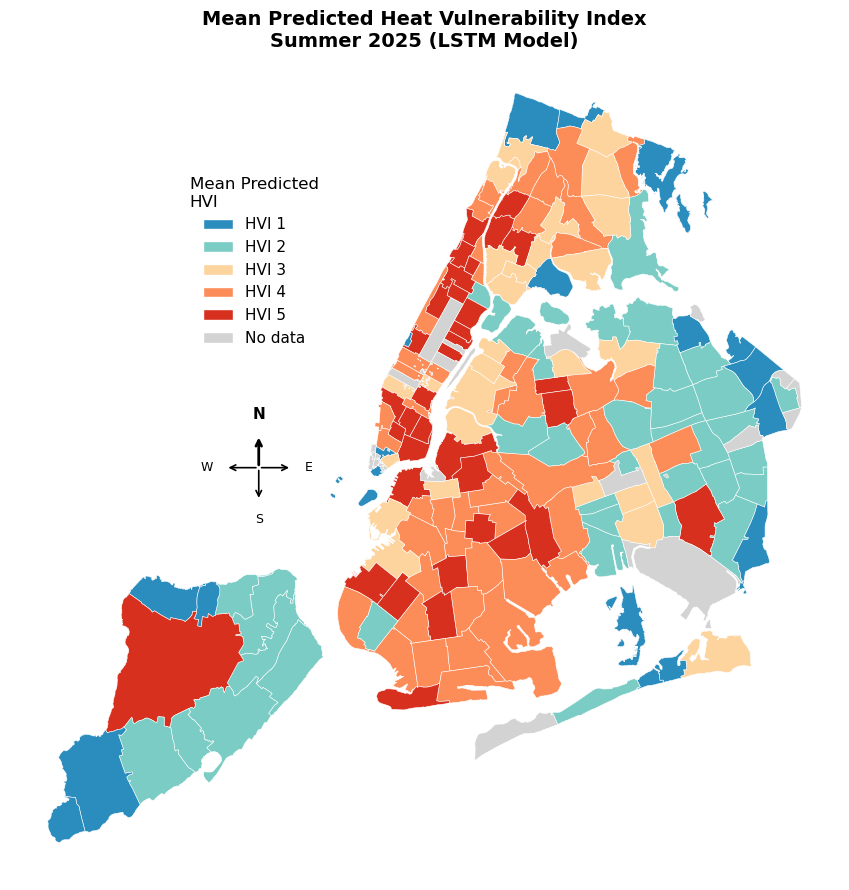

In [2]:
# ----- MAP PLOT OF MEAN HVI FOR SUMMER 2025 -----
predictions['date'] = pd.to_datetime(predictions['date'])
summer_2025 = predictions[
    (predictions['date'].dt.year == 2025) &
    (predictions['date'].dt.month.isin([6, 7, 8]))
]
mean_hvi = summer_2025.groupby('zip')['lstm_pred'].mean().reset_index()
mean_hvi.columns = ['zip', 'mean_hvi']

# merge with shapefile
nyc_zips['zip'] = nyc_zips['postalCode'].astype(int)
merged = nyc_zips.merge(mean_hvi, on='zip', how='left')

# colormap for HVI
color_map = {
    1: '#2b8cbe',
    2: '#7bccc4',
    3: '#fdd49e',
    4: '#fc8d59',
    5: '#d7301f',
}
colors = [color_map[i] for i in range(1, 6)]
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], ncolors=5)

# make map plot
fig, ax = plt.subplots(1, 1, figsize=(10, 9))

merged.plot(
    column='mean_hvi',
    ax=ax,
    cmap=cmap,
    norm=norm,
    edgecolor='white',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey', 'edgecolor': 'white', 'label': 'No data'}
)

ax.set_title('Mean Predicted Heat Vulnerability Index\nSummer 2025 (LSTM Model)', fontsize=14, fontweight='bold')
ax.axis('off')

# add a compass rose
cx, cy = 0.3, 0.5   # axes fraction coordinates
arrow_len = 0.04

# N arrow
ax.annotate('', xy=(cx, cy + arrow_len), xytext=(cx, cy),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
# S
ax.annotate('', xy=(cx, cy - arrow_len), xytext=(cx, cy),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2))
# E
ax.annotate('', xy=(cx + arrow_len, cy), xytext=(cx, cy),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2))
# W
ax.annotate('', xy=(cx - arrow_len, cy), xytext=(cx, cy),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

offset = 0.055
ax.text(cx, cy + offset, 'N', ha='center', va='bottom', fontsize=11, fontweight='bold', transform=ax.transAxes)
ax.text(cx, cy - offset, 'S', ha='center', va='top',    fontsize=9,  transform=ax.transAxes)
ax.text(cx + offset, cy, 'E', ha='left',   va='center', fontsize=9,  transform=ax.transAxes)
ax.text(cx - offset, cy, 'W', ha='right',  va='center', fontsize=9,  transform=ax.transAxes)


# add a legend at the bottom 
legend_elements = [
    Patch(facecolor=color_map[i], edgecolor='white', label=f'HVI {i}')
    for i in range(1, 6)
]
legend_elements.append(Patch(facecolor='lightgrey', edgecolor='white', label='No data'))

ax.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(0.2, 0.75),
    ncol=1,
    frameon=False,
    fontsize=11,
    title='Mean Predicted\nHVI',
    title_fontsize=12
)

plt.tight_layout()
plt.savefig('model/hvi_map_summer2025.png', dpi=150, bbox_inches='tight')
plt.show()

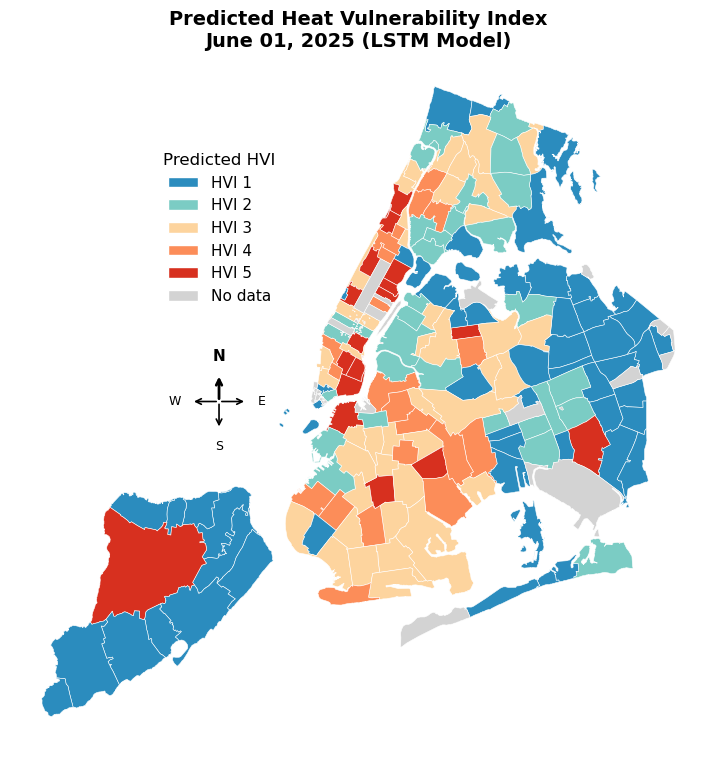

In [3]:
# ----- MAP GIF OF TIME-EVOLVING HVI FOR SUMMER 2025 -----

dates = sorted(summer_2025['date'].unique())

fig, ax = plt.subplots(1, 1, figsize=(10, 9))

def update(date):
    ax.clear()
    daily = predictions[predictions['date'] == date].groupby('zip')['lstm_pred'].mean().reset_index()
    daily.columns = ['zip', 'hvi']
    day_merged = nyc_zips.merge(daily, on='zip', how='left')
    day_merged.plot(
        column='hvi',
        ax=ax,
        cmap=cmap,
        norm=norm,
        edgecolor='white',
        linewidth=0.4,
        missing_kwds={'color': 'lightgrey', 'edgecolor': 'white', 'label': 'No data'}
    )
    ax.set_title(f'Predicted Heat Vulnerability Index\n{pd.Timestamp(date).strftime("%B %d, %Y")} (LSTM Model)',
                 fontsize=14, fontweight='bold')
    ax.axis('off')

    # compass rose
    cx, cy = 0.3, 0.5
    arrow_len = 0.04
    for dx, dy in [(0, arrow_len), (0, -arrow_len), (arrow_len, 0), (-arrow_len, 0)]:
        ax.annotate('', xy=(cx+dx, cy+dy), xytext=(cx, cy),
                    xycoords='axes fraction', textcoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color='black',
                                   lw=2 if dy == arrow_len else 1.2))
    offset = 0.055
    ax.text(cx, cy + offset, 'N', ha='center', va='bottom', fontsize=11, fontweight='bold', transform=ax.transAxes)
    ax.text(cx, cy - offset, 'S', ha='center', va='top',    fontsize=9,  transform=ax.transAxes)
    ax.text(cx + offset, cy, 'E', ha='left',   va='center', fontsize=9,  transform=ax.transAxes)
    ax.text(cx - offset, cy, 'W', ha='right',  va='center', fontsize=9,  transform=ax.transAxes)

    # legend
    legend_elements = [
        Patch(facecolor=color_map[i], edgecolor='white', label=f'HVI {i}')
        for i in range(1, 6)
    ]
    legend_elements.append(Patch(facecolor='lightgrey', edgecolor='white', label='No data'))
    ax.legend(
        handles=legend_elements,
        loc='center left',
        bbox_to_anchor=(0.2, 0.75),
        ncol=1,
        frameon=False,
        fontsize=11,
        title='Predicted HVI',
        title_fontsize=12
    )

ani = FuncAnimation(fig, update, frames=dates, interval=200)
ani.save('model/hvi_animation_summer2025.gif', writer=PillowWriter(fps=5))